# Modelo Preditivo de NPS — Tech Challenge

## Visão Geral

Neste notebook construímos um **modelo de classificação** capaz de prever se um cliente será **Detrator**, **Neutro** ou **Promotor** com base em variáveis operacionais do pedido.

### Etapas

1. Carregamento dos dados
2. Definição da variável alvo (`nps_class`)
3. Seleção e preparação das features
4. Divisão treino/teste
5. Treinamento do modelo (Random Forest)
6. Avaliação dos resultados

### Instalação de dependências

In [10]:
%pip install pandas scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Importação das bibliotecas

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

### 1. Carregamento dos dados

Carregamos o dataset bruto do Tech Challenge a partir do arquivo CSV.

In [12]:
df = pd.read_csv('../data/raw/desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### 2. Definição da variável alvo (`nps_class`)

Criamos a coluna `nps_class` categorizando cada cliente com base na sua nota NPS:

- **Detrator** (nota 0–6): clientes insatisfeitos
- **Neutro** (nota 7–8): clientes indiferentes
- **Promotor** (nota 9–10): clientes entusiastas

Essa será a variável que o modelo tentará prever.

In [13]:
def categorize_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_class'] = df['nps_score'].apply(categorize_nps)

df['nps_class'].value_counts()

nps_class
Detrator    1851
Neutro       448
Promotor     201
Name: count, dtype: int64

### 3. Seleção e preparação das features

Com base na análise exploratória, selecionamos as **variáveis com maior correlação com o NPS** — em vez de usar todas as colunas, focamos nas que mais explicam a satisfação do cliente:

- `delivery_delay_days` — dias de atraso na entrega (maior impacto negativo no NPS)
- `customer_service_contacts` — frequência de contatos com suporte
- `resolution_time_days` — tempo para resolução de problemas
- `complaints_count` — número de reclamações registradas
- `repeat_purchase_30d` — recompra em 30 dias (sinal de satisfação)
- `csat_internal_score` — score interno de satisfação

Além disso, aplicamos `get_dummies` na variável regional para capturar diferenças geográficas.

In [14]:
FEATURES = [
    'delivery_delay_days',
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',
    'repeat_purchase_30d',
    'csat_internal_score',
    'customer_region',
]

X = df[FEATURES].copy()
y = df['nps_class']

X = pd.get_dummies(X, columns=['customer_region'], drop_first=True)
X = X.fillna(X.median(numeric_only=True))

print(f'Features: {X.shape[1]} colunas | Amostras: {X.shape[0]} linhas')
X.head()

Features: 10 colunas | Amostras: 2500 linhas


,delivery_delay_days,customer_service_contacts,resolution_time_days,complaints_count,repeat_purchase_30d,csat_internal_score,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,2,0,4,3,0,6.5,True,False,False,False
1,4,0,10,3,0,0.0,False,False,False,True
2,1,4,5,7,0,1.5,True,False,False,False
3,2,1,11,4,0,0.3,False,False,False,False
4,1,1,0,3,0,7.9,False,True,False,False


### 4. Divisão treino / teste

Dividimos os dados em:
- **80% treino** — usado para o modelo aprender os padrões
- **20% teste** — usado para validar o desempenho em dados nunca vistos

O parâmetro `stratify=y` garante que a proporção de cada classe (Detrator, Neutro, Promotor) seja mantida igualmente nos dois conjuntos.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

Treino: 2000 amostras
Teste:  500 amostras


### 5. Treinamento do modelo — Random Forest com GridSearchCV

Optamos pelo **Random Forest Classifier** pelos seguintes motivos:

- Lida bem com múltiplas variáveis operacionais ao mesmo tempo
- Menor risco de *overfitting* em comparação com árvores simples
- Fornece importância das features nativamente

Para melhorar a performance, aplicamos duas estratégias adicionais:

- **`class_weight='balanced'`** — ajusta automaticamente o peso das classes para lidar com possível desbalanceamento entre Detratores, Neutros e Promotores
- **`GridSearchCV`** — busca sistemática pelos melhores hiperparâmetros (`n_estimators`, `max_depth`, `min_samples_split`) usando validação cruzada de 5 folds

Optamos pelo **Random Forest Classifier** pelos seguintes motivos:

- Lida bem com múltiplas variáveis operacionais ao mesmo tempo
- Menor risco de *overfitting* em comparação a uma árvore de decisão simples
- Não exige normalização dos dados
- Fornece a importância de cada feature nativamente

In [16]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print(f'Melhores hiperparâmetros: {grid_search.best_params_}')
print(f'Melhor F1-macro (CV): {grid_search.best_score_:.4f}')
print('Modelo treinado com sucesso!')

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Melhores hiperparâmetros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Melhor F1-macro (CV): 0.7892
Modelo treinado com sucesso!


### 6. Validação cruzada

Antes de avaliar no conjunto de teste, verificamos a **estabilidade do modelo** com validação cruzada de 5 folds no conjunto de treino. Isso garante que a performance não depende de uma única divisão aleatória dos dados.

Avaliamos o modelo no conjunto de teste usando o **relatório de classificação**, que apresenta para cada classe:

- **Precision** — dos que o modelo previu como X, quantos realmente eram X
- **Recall** — dos que realmente eram X, quantos o modelo acertou
- **F1-score** — média harmônica entre precision e recall
- **Support** — número de amostras reais de cada classe no conjunto de teste

In [17]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'F1-macro por fold: {[round(s, 4) for s in cv_scores]}')
print(f'Média: {cv_scores.mean():.4f} | Desvio padrão: {cv_scores.std():.4f}')

F1-macro por fold: [np.float64(0.8322), np.float64(0.7794), np.float64(0.7618), np.float64(0.8104), np.float64(0.762)]
Média: 0.7892 | Desvio padrão: 0.0279


### 7. Avaliação no conjunto de teste

Avaliamos o modelo no conjunto de teste usando o **relatório de classificação**, que apresenta para cada classe:

- **Precision** — dos que o modelo previu como X, quantos realmente eram X
- **Recall** — dos que realmente eram X, quantos o modelo identificou corretamente
- **F1-score** — média harmônica entre Precision e Recall

In [18]:
y_pred = model.predict(X_test)

print('Relatório de Classificação (Performance no conjunto de teste):')
print(classification_report(y_test, y_pred))

Relatório de Classificação (Performance no conjunto de teste):
              precision    recall  f1-score   support

    Detrator       0.91      0.86      0.88       370
      Neutro       0.51      0.61      0.56        90
    Promotor       0.93      1.00      0.96        40

    accuracy                           0.82       500
   macro avg       0.78      0.82      0.80       500
weighted avg       0.84      0.82      0.83       500



### 8. Matriz de Confusão

A matriz de confusão mostra onde o modelo acerta e onde erra, permitindo identificar se há confusão sistemática entre classes (ex: Neutro sendo classificado como Detrator).

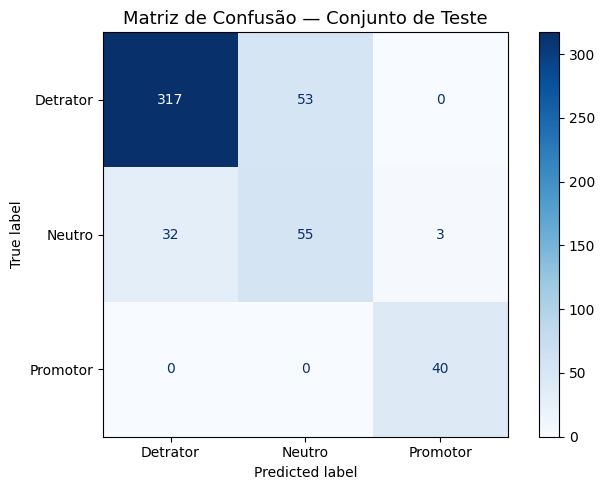

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Detrator', 'Neutro', 'Promotor'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusão — Conjunto de Teste', fontsize=13)
plt.tight_layout()
plt.show()

### 9. Importância das Features

Visualizamos quais variáveis o modelo considera mais relevantes para a predição do NPS. Isso valida nossa seleção de features e pode orientar decisões operacionais.

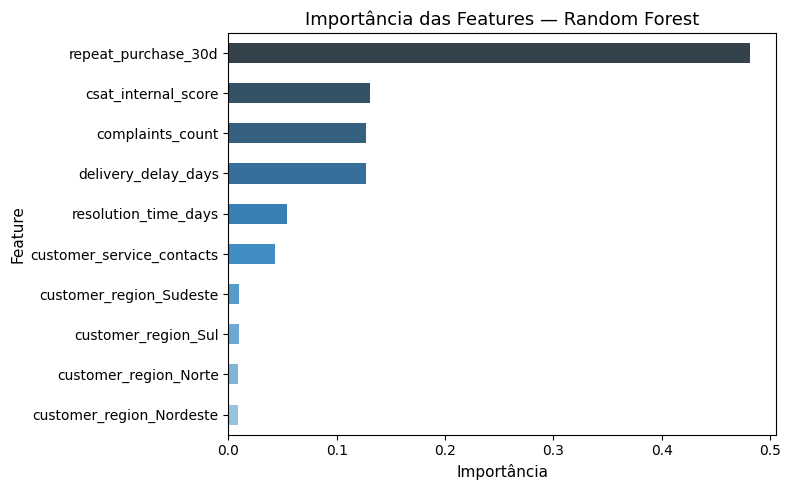

In [20]:
importancias = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
cores = sns.color_palette('Blues_d', len(importancias))
importancias.plot(kind='barh', color=cores, ax=ax)

ax.set_title('Importância das Features — Random Forest', fontsize=13)
ax.set_xlabel('Importância', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

### 7 Gerador para leitura de dockertfile

In [21]:
import joblib
import os

# Garante que a pasta 'models' exista um nível acima da pasta 'notebooks'
os.makedirs('../models', exist_ok=True)

# Salva o modelo treinado
joblib.dump(model, '../models/modelo_nps.pkl')
print("IA salva com sucesso na pasta models")

IA salva com sucesso na pasta models
